# Part 1
## (ii) Isotherm annealing: Analytical solution 

Result: plot of concentration vs distance and contration gradient vs distance 
Self diffusion of Ni* and Cu* tracer atoms in bars of Ni and Cu, respectively. 

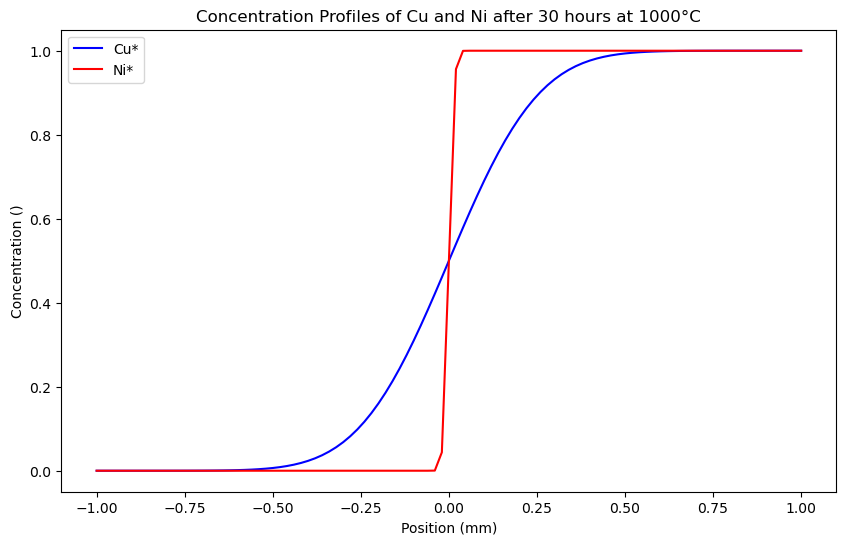

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd

# Problem parameters
T=1000+273.15 # K
t_tot=30*3600 # s
R=8.314 # J/mol*K
x = np.linspace(-1e-3, 1e-3, 101) # m, i.e. from -1 mm to 1 mm

# Material parameters (experimental values from table 2.2 in Porter et al. Phase Transformations in Metals and Alloys)
D0_Cu=31e-6 # m^2/s
D0_Ni=190e-6 # m^2/s
Q_Cu=200.3 # kJ/mol
Q_Ni=279.7 # kJ/mol

# Diffusion coefficient function, D(T)
def Diff_coeff(T, D0, Q):
    return D0*np.exp(-Q*1000/(R*T))

D_Cu=Diff_coeff(T, D0_Cu, Q_Cu)
D_Ni=Diff_coeff(T, D0_Ni, Q_Ni)

# Concentration profile function, C(x,t)
def Concentration_profile(x, t, D, C1, C2):
    return (C1+C2)/2 - (C1-C2)/2 * math.erf(x/(2*np.sqrt(D*t)))

# Calculating concentration profiles for Cu and Ni, with inital condtion: 
# C(x,1)= 1 for x>0 and C(x,1)= 0 for x<0
C_Cu = []  
C_Ni = []

for xi in x:
    C_Cu.append(Concentration_profile(xi, t_tot, D_Cu, 0, 1))
    C_Ni.append(Concentration_profile(xi, t_tot, D_Ni, 0, 1))

# Plotting the concentration profiles
plt.figure(figsize=(10, 6))
plt.plot(x*1e3, C_Cu, label='Cu*', color='blue')
plt.plot(x*1e3, C_Ni, label='Ni*', color='red')
plt.title('Concentration Profiles of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)')     
plt.ylabel('Concentration ()')
plt.legend()
plt.legend()


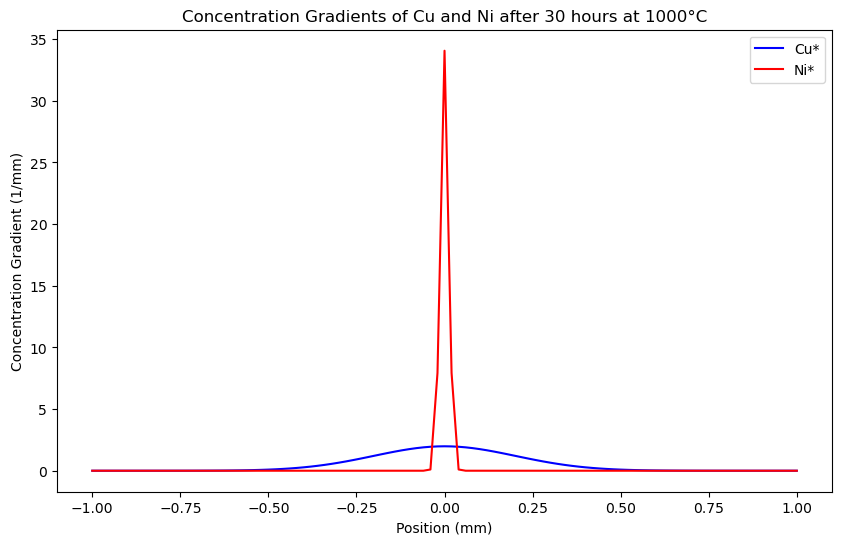

In [3]:
# Concetraion gradients
def Concentration_gradient(x, t, D, C1, C2):
    return -(C1-C2)/(2*np.sqrt(np.pi*D*t)) * np.exp(-x**2/(4*D*t))

Cons_Cu_grad = []
Cons_Ni_grad = []

for xi in x:
    Cons_Cu_grad.append(Concentration_gradient(xi, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
    Cons_Ni_grad.append(Concentration_gradient(xi, t_tot, D_Ni, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm

plt.figure(figsize=(10, 6))
plt.plot(x*1e3, Cons_Cu_grad, label='Cu*', color='blue')
plt.plot(x*1e3, Cons_Ni_grad, label='Ni*', color='red')
plt.title('Concentration Gradients of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)') 
plt.ylabel('Concentration Gradient (1/mm)')
plt.legend()        

In [4]:
# sanity checks
print(Concentration_gradient(0, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
print(D_Cu)
print(D_Ni) #NB, diffusion of Ni is very slow, out of the expected range for fcc metals, but this is what the experimental data says.
# Explaination is that 1000°C is further away from the melting point of Ni than Cu, so diffusion is slower.

1.9819491252865742
1.875777731342469e-13
6.351002637027351e-16


## iii) Numerical solution by finite difference method with explisit timesteps

Numerical solution to substitutional self-diffusion of tracer atoms in bar. I.e. Cu* in Cu and Ni* in Ni (diffusion couple) 

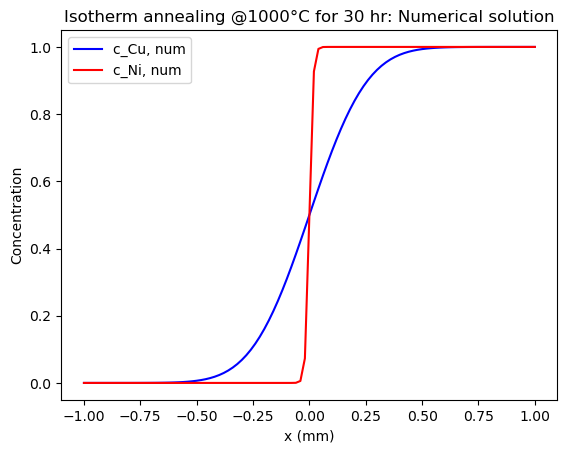

In [41]:
dx_mm = 0.02              # spatial step in mm
dx = dx_mm * 1e-3         # spatial step in m
dt=600 # timestep, seconds (should be within bounds of stability, i.e. dt < dx^2/(2*D))

N = int(t_tot/ dt)   # number of time steps
M = int(2/dx_mm)       # number of spatial steps

# Grid 
x = np.linspace(-1, 1, M+1) # mm
c = np.zeros(M+1)

# Boundary conditions 
# c(x,0) = 1 for x>0, 0 for x<0  
c[x > 0] = 1
c[x < 0] = 0
c[x == 0] = 0.5 # Condition at midpoint

def num_sol(D, c0, dt, dx, N, M):
    """
    D  : diffusion coefficient (m^2/s)
    c0 : initial concentration array (copy of your initial condition)
    dt, dx : time and space steps
    N  : number of time steps
    M  : number of spatial intervals (len(c0) - 1)
    """
    c = c0.copy()   # don't overwrite the caller's original initial condition
    for n in range(N):
        c_new = c.copy()
        for m in range(1, M):
            c_new[m] = D*dt/dx**2 * (c[m+1] - 2*c[m] + c[m-1]) + c[m]
        c_new[0] = c0[0]   # Dirichlet: hold at initial boundary values
        c_new[M] = c0[M]
        c = c_new
    return c

c_Cu = num_sol(D_Cu, c, dt, dx, N, M)
c_Ni = num_sol(D_Ni, c, dt, dx, N, M)

plt.plot(x, c_Cu, label='c_Cu, num', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num', color='red')
plt.xlabel('x (mm)')
plt.ylabel('Concentration')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()



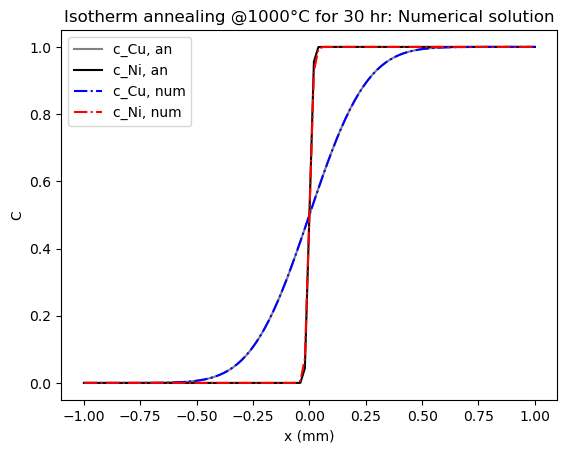

In [6]:
# Plot with analytical solution for comparison 
plt.plot(x, C_Cu, label='c_Cu, an',color='grey')
plt.plot(x, C_Ni, label='c_Ni, an', color='black')
plt.plot(x, c_Cu, label='c_Cu, num',linestyle='dashdot', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num',linestyle='dashdot', color='red')
plt.xlabel('x (mm)')
plt.ylabel('C')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()

## Part 2
### i) Calculate and plot D for the composition range
We are trying to plot fig. 2.21 in Porter and Easterling by linearising between the endpoints. The endpoints themselves are extracted from the figure.

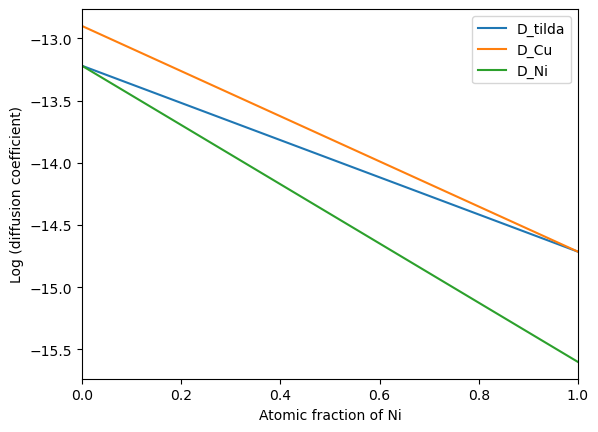

In [10]:
X_A=np.linspace(0,1,100)
values = pd.read_csv('D_tilda.csv', sep=';', header=None, decimal=',') # henter grafen til Vegard, men bruker bare endepunktene

D_Ni1= values.iloc[0, 1]
D_Ni2= -15.6
D_Cu2= values.iloc[-1, 1]
D_Cu1= -12.9

def D_Cu_lin(X_A):
    return D_Cu1-(D_Cu1-D_Cu2)*X_A

def D_Ni_lin(X_A):
    return D_Ni1-(D_Ni1-D_Ni2)*X_A

#Linear D̃
def D_tilda_lin(X_A):
    return (1-X_A)*D_Ni1+X_A*D_Cu2



plt.plot(X_A, D_tilda_lin(X_A), label='D_tilda')
plt.plot(X_A, D_Cu_lin(X_A), label='D_Cu')
plt.plot(X_A, D_Ni_lin(X_A), label='D_Ni')
plt.xlabel('Atomic fraction of Ni')
plt.ylabel('Log (diffusion coefficient, m^2/s)')
plt.margins(x=0)
plt.legend()
plt.show()

### iii) Diffusion profile, explisit method

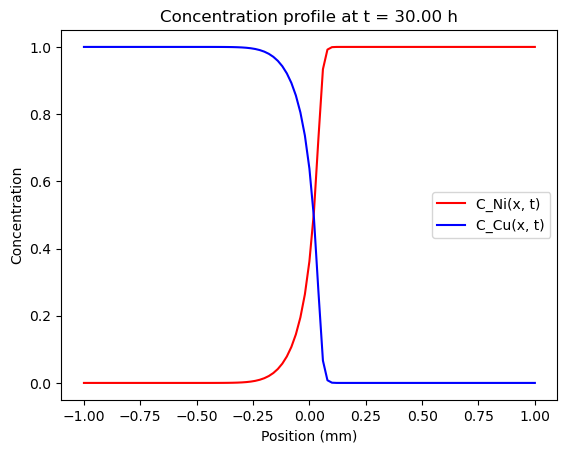

1588.6564694485644


In [40]:
dx_mm = 0.02              # spatial step in mm
dx = dx_mm * 1e-3         # spatial step in m
t_tot=3600*30

N = int(t_tot/ dt)   # number of time steps
M = int(2/dx_mm)       # number of spatial steps

# Grid 
x = np.linspace(-1, 1, M+1) # mm
c = np.zeros(M+1)

# Boundary conditions 
# c(x,0) = 1 for x>0, 0 for x<0  
c[x > 0] = 1
c[x < 0] = 0
c[x == 0] = 0.5 # Condition at midpoint

# Diffusion coefficients, non log
def D_tilda_of_c(c_vec):
    return 10**np.interp(c_vec, X_A, D_tilda_lin)

# Stability limited timestep
D_max = max(10**D_Ni1, 10**D_Ni2, 10**D_Cu1, 10**D_Cu2)
dt_stability = dx**2 / (2 * D_max)  # stability condition
dt=0.5 * dt_stability  # set dt to half the stability limit for safety
N = int(t_tot/ dt)   # recalculate number of time steps based on new dt

# Time integration loop (explicit finite difference scheme)
def num_sol_nonlinear(c, D_tilda_lin, dx, dt, N, M):
        c_new = c.copy()
        for n in range(N): # time stepping loop
            for m in range(1, M): # spatial loop
                D = D_tilda_lin(c)
                D_half= 0.5 * (D[:-1] + D[1:])
                c_new[m] = c[m] + (dt/dx**2)*(D_half[m]*(c[m+1] - c[m]) - D_half[m-1]*(c[m] - c[m-1]))

            # Apply boundary conditions
            c_new[0] = c[0]  # Dirichlet BC at the left boundary
            c_new[-1] = c[-1]  # Dirichlet BC at the right boundary
            c = c_new.copy()

        return c_new


c_Ni = num_sol_nonlinear(c, D_tilda_of_c, dx, dt, N, M)
c_Cu = 1-c_Ni

# Plot the final concentration profile
plt.plot(x, c_Ni, color='red', label='C_Ni(x, t)')
plt.plot(x, c_Cu, color='blue', label='C_Cu(x, t)')
plt.title('Concentration profile at t = {:.2f} h'.format(t_tot/3600))
plt.xlabel('Position (mm)')
plt.ylabel('Concentration')
plt.legend()
plt.show()

print(dt_stability)
